In [1]:
import sys, os
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/TPN_DeV")
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from tensorflow_probability.substrates import jax as tfp

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
dtype = jnp.float64

# Other tools.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
# Import TriplePandel stuff

from lib.simdata_i3 import I3SimHandler
# from lib.linefit import linefit_3d_time
from lib.geo import center_track_pos_and_time_based_on_data
from lib.gupta_network_eqx_4comp import get_network_eval_v_fn, get_network_eval_v_fn_f32
from lib.experimental_methods import get_vertex_seeds
from fitting.llh_scanner import get_scanner
from fitting.llh_fitter import get_fitter
from dom_track_eval import get_eval_network_doms_and_track
from likelihoods.likelihood_conv_mpe_logsumexp_gupta import get_neg_c_triple_gamma_llh
from lib.linefit import linefit_3d_time_np
# A custom color scheme
from palettable.cubehelix import Cubehelix
cx = Cubehelix.make(start=0.3, rotation=-0.5, n=16, reverse=False, gamma=1.0,
     	max_light=1.0,max_sat=0.5, min_sat=1.4).get_mpl_colormap()

# Specify the grid.
dzen = 0.07 # rad
dazi = 0.07 # rad
n_eval = 50 # number of grid points per axes

# Assume 4-component gupta by default
n_hidden = 96
gupta = True
n_comp = 4

2025-12-12 11:49:47.164140: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22645/tfrecords/ftr/'
META_FILE_NAME = 'meta_ds_22645_from_0_to_1000_10_to_100TeV.ftr'
PULSES_FILE_NAME = 'pulses_ds_22645_from_0_to_1000_10_to_100TeV.ftr'

In [3]:
def get_event_data(event_index: int) -> pd.DataFrame:
    ev_idx = event_index
    event_meta = events_meta.iloc[ev_idx]
    print(event_meta)
    event_id = event_meta['event_id']
    
    event_data = events_data[events_data['event_id'] == event_id].copy()
    return event_meta, event_data

In [4]:
def get_per_dom_summary_from_sim_data(
    meta: pd.DataFrame,
    pulses: pd.DataFrame,
    charge_key='charge',
    correct_charge=False) -> pd.DataFrame:

    df_qtot = pulses[['sensor_id', charge_key]].groupby(by=['sensor_id'], as_index=False).sum()
    df_tmin = pulses[['sensor_id', 'time']].groupby(by=['sensor_id'], as_index=False).min()
    df = df_qtot.merge(geo.iloc[df_qtot['sensor_id']], on='sensor_id', how='outer')
    df['time'] = df_tmin['time'].values

    if correct_charge == True:
        df_corr = pulses[['sensor_id', 'charge_correction']].groupby(by=['sensor_id'], as_index=False).mean()
        df['charge'] = df['charge'].values * df_corr['charge_correction'].values

    if charge_key != 'charge':
        df.rename({charge_key: 'charge'}, inplace=True, axis='columns')
    return df

In [5]:
def replace_early_pulse(summary_data, pulses):
    corrected_time = np.zeros(len(summary_data))
    for i, row in summary_data.iterrows():
        s_id = row['sensor_id']
        q_tot = row['charge']
        t1 = row['time']

        idx = pulses['sensor_id'] == s_id
        pulses_this_dom = pulses[idx]
        corrected_time[i] = get_first_regular_pulse(pulses_this_dom, t1, q_tot)



    summary_data['time'] = corrected_time

In [6]:
def get_first_regular_pulse(pulses, t1, q_tot, crit_delta=10, crit_ratio = 5.e-3, crit_charge=100.):
    # technically, if we do remove early pulses, one could correct the total charge.
    # in practice, this would be an epsilon correction. Not worth adding the extra code complexity.
    # calculate ratio of charge within 10ns and 75ns of hit.
    if q_tot < crit_charge:
        return t1

    n = len(pulses)
    charge = pulses['charge'].to_numpy()
    time = pulses['time'].to_numpy()
    crit_delta_long = 75

    j = 0 # pts to end of crit_delta interval
    k = 0 # pts to end of crit_delta_long interval
    q_veto = 0
    q_long = 0
    for i in range(0, n):
        crit_time = time[i] + crit_delta
        if j < i:
            j = i

        # extend window
        while j < n and time[j] < crit_time:
            q_veto += charge[j]
            j += 1

        crit_time = time[i] + crit_delta_long
        if k < i:
            k = i

        # extend window
        while k < n and time[k] < crit_time:
            q_long += charge[k]
            k += 1

        r_veto = q_veto / q_long
        if r_veto > crit_ratio:
            # found a reasonable pulse
            # break
            break

        # remove early pulse
        q_long -= charge[i]
        q_veto -= charge[i]

    return time[i]

In [7]:
def plot_event(df, index, geo=None, outfile=None, plot_pdf=None):
    fig = plt.figure(figsize=(12,8))
    ax = plt.subplot(projection='3d')
    ax.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)

    try:
        im = ax.scatter(geo['x'], geo['y'], geo['z'], s=0.9, c='0.7', alpha=0.8)
    except:
        pass

    im = ax.scatter(df['x'], df['y'], df['z'], s=np.sqrt(df['charge']*100), c=df['time'],
                    cmap='rainbow_r',  edgecolors='k', zorder=1000)
    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    cb = plt.colorbar(im, orientation="vertical", pad=0.1)
    cb.set_label(label='time [ns]', size='x-large')
    cb.ax.tick_params(labelsize='x-large')
    plt.title(f'Event {index}')
    if plot_pdf:
        pdf.savefig()
        plt.close()
    else:
        plt.show()
    # if outfile is None:
    #     plt.show()

    # else:
    #     plt.savefig(outfile, dpi=300)

event_id                   226450000105727.0
idx_start                                0.0
idx_end                                216.0
n_channel_HLC                           60.0
neutrino_energy                218136.485932
muon_energy                     48620.005076
muon_energy_at_detector          6986.870942
muon_energy_lost                 1323.158379
q_tot                                  205.8
n_channel                               89.0
muon_zenith                         2.306088
muon_azimuth                        2.321341
muon_time                         4186.28876
muon_pos_x                      -1210.055136
muon_pos_y                       1353.599094
muon_pos_z                      -1639.951857
spline_mpe_zenith                   2.302529
spline_mpe_azimuth                  2.322417
spline_mpe_time                 11783.568778
spline_mpe_pos_x                  -58.517072
spline_mpe_pos_y                  117.034483
spline_mpe_pos_z                 -113.151377
Name: 5, d

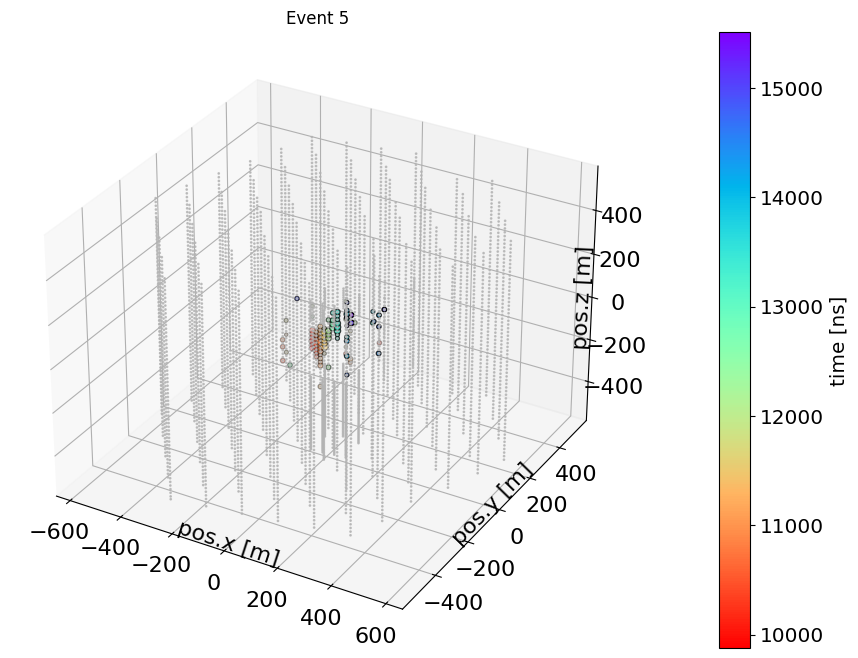

In [177]:
EVENT_INDEX=5
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'
geo = pd.read_csv(geo_file)

events_meta_file = os.path.join(PATH_TO_INPUT, META_FILE_NAME)
events_pulses_file = os.path.join(PATH_TO_INPUT, PULSES_FILE_NAME)
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'

events_meta = pd.read_feather(events_meta_file)
events_data = pd.read_feather(events_pulses_file)
geo = pd.read_csv(geo_file)


int_cols_meta = ["event_id", "idx_start", "idx_end", "n_channel_HLC", "n_channel"]
events_meta[int_cols_meta] = events_meta[int_cols_meta].astype("Int64")

int_cols_data = ["event_id", "sensor_id", "is_HLC"]
events_data[int_cols_data] = events_data[int_cols_data].astype("Int64")

meta, pulses = get_event_data(EVENT_INDEX)
print(f"muon energy: {meta['muon_energy_at_detector']/1.e3:.1f} TeV")

# Get dom locations, first hit times, and total charges (for each dom).
event_data = get_per_dom_summary_from_sim_data(meta, pulses)

# Remove early pulses.
replace_early_pulse(event_data, pulses)
print("n_doms", len(event_data))

# Get MCTruth.
true_pos = jnp.array([meta['muon_pos_x'], meta['muon_pos_y'], meta['muon_pos_z']])
print(true_pos)
true_time = meta['muon_time']
true_zenith = meta['muon_zenith']
true_azimuth = meta['muon_azimuth']
true_src = jnp.array([true_zenith, true_azimuth])
true_src_deg = np.rad2deg(true_src)
print("true direction:", true_src)
print("true direction:", true_src_deg)
plot_event(event_data, EVENT_INDEX, geo=geo)

In [178]:
%load_ext autoreload
%autoreload 2
from lib.geo import center_track_pos_and_time_based_on_data
from lib.linefit import linefit_3d_time_np

track_pos = true_pos
track_time = true_time
track_zenith = true_zenith
track_azimuth = true_azimuth
track_src = true_src


track_pos1 = jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']])
track_time1 = meta['spline_mpe_time']
track_zenith1 = meta['spline_mpe_zenith']
track_azimuth1 = meta['spline_mpe_azimuth']
track_src1 = jnp.array([track_zenith1, track_azimuth1])


track_pos2, track_time2, _,  track_src2 = linefit_3d_time_np(event_data)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [179]:
type(event_data)

pandas.core.frame.DataFrame

In [180]:
track_src

Array([2.30608838, 2.32134133], dtype=float64)

In [181]:
track_src1

Array([2.30252852, 2.32241688], dtype=float64)

In [182]:
track_src2

Array([2.28701492, 2.28321136], dtype=float64)

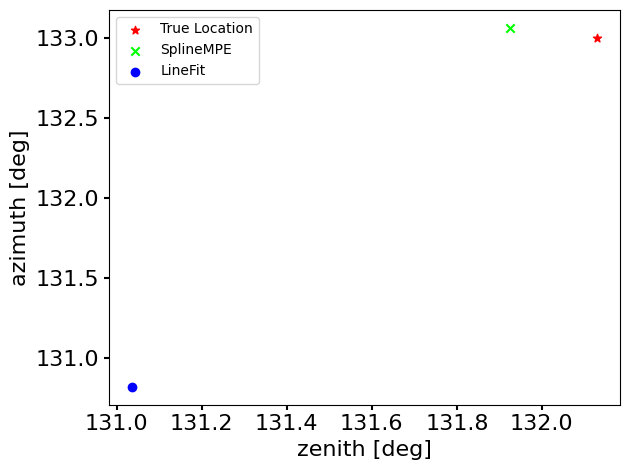

In [183]:
# Plot.
fig, ax = plt.subplots()

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="True Location", zorder=200)
ax.scatter(np.rad2deg(track_src1[0]), np.rad2deg(track_src1[1]), marker="x", color='lime', label="SplineMPE", zorder=200)
ax.scatter(np.rad2deg(track_src2[0]), np.rad2deg(track_src2[1]), marker="o", color='blue', label="LineFit", zorder=200)
# ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
# ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
# ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))
ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)

plt.legend()
plt.tight_layout()
# plt.savefig(f"f32_scan_ev_{EVENT_INDEX}.png", dpi=300)
# plt.savefig(f"{ni}_scan_ev_{EVENT_INDEX}.png", dpi=300)
plt.show()

track_pos shape: (3,)
track_time shape: (1,)
track_dir shape: (1, 2)
track_dir_xyz shape: (3, 2)


track_pos shape: (3,)
track_time shape: ()
track_dir shape: (2,)
track_dir_xyz shape: (3,)

In [191]:
%load_ext autoreload
%autoreload 2
from lib.geo import center_track_pos_and_time_based_on_data

print("seed direction:", np.rad2deg(track_src2), "deg")
print("original seed vertex:", track_pos2, "m")
center_track_seed = True
track_pos2 = jnp.array(np.asarray(track_pos2, dtype=float))
track_time2 = jnp.array([track_time2])
track_src2 = jnp.array([track_src2])
track_src2=track_src2.squeeze()

centered_track_pos, centered_track_time = track_pos, track_time
if center_track_seed:
    # print("shifting seed vertex.")
    centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos2, track_time2, track_src2)

print("seed vertex:", centered_track_pos, "m")


# print("seed direction:", np.rad2deg(track_src1), "deg")
# print("original seed vertex:", track_pos1, "m")
# centered_track_pos, centered_track_time = track_pos1, track_time1
# if center_track_seed:
#     centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos1, track_time1, track_src1)
# print("splinempe seed vertex:", centered_track_pos, "m")

# centered_track_pos, centered_track_time = track_pos1, track_time1
# if center_track_seed:
#     centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)
# print("truth vertex:", centered_track_pos, "m")

fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
print(fitting_event_data.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
seed direction: [131.03630261 130.81837489] deg
original seed vertex: [ -69.37044944  128.57191011 -128.86685393] m
seed vertex: [[-143.56234924  214.46834607 -227.65870299]] m
(89, 5)


In [192]:
network_path = '../data/gupta/n96_4comp_w_penalty_1.e-4/new_model_no_penalties_tree_start_epoch_1000.eqx'
eval_network_v = get_network_eval_v_fn(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
eval_network_doms_and_track = get_eval_network_doms_and_track(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)

In [193]:
GAUS_CONV_WIDTH = 3.0
neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=GAUS_CONV_WIDTH)

In [194]:
use_multiple_vertex_seeds = True
prescan_time = True
fit_llh = get_fitter(
                        neg_llh,
                        use_multiple_vertex_seeds=use_multiple_vertex_seeds,
                        prescan_time=prescan_time
                    )

# JIT! We want it to be fast.
fit_llh_jit = jax.jit(fit_llh)

# Run the fit
solution = fit_llh_jit(track_src2, centered_track_pos, centered_track_time, fitting_event_data)
best_logl, best_direction, best_vertex, best_time= solution

print("")
print("solution found.")
print(f"logl: {best_logl:.3f}")
print(f"direction: {np.rad2deg(best_direction)} deg")
print("")


solution found.
logl: 1144.106
direction: [135.14252474 131.25334653] deg



smpe

solution found.
logl: 1050.361
direction: [132.02199555 133.4184431 ] deg


In [188]:
n_eval = 30
N_SPLITS = 15

scan_llh = get_scanner(
                        neg_llh,
                        use_multiple_vertex_seeds=use_multiple_vertex_seeds,
                        prescan_time=prescan_time,
                        n_splits=N_SPLITS,
                        use_jit=True
                    )

zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
X, Y = jnp.meshgrid(zenith, azimuth)

print("running the scan.")

running the scan.


In [189]:
solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)
# use below if you want to use original seed values (not best-fit values)
# as seed for vertex minimization during scan.
# solution = scan_llh(X, Y, centered_track_pos, centered_track_time, fitting_event_data)

sol_logl, sol_vertex, sol_time = solution
logls = sol_logl.reshape(X.shape)

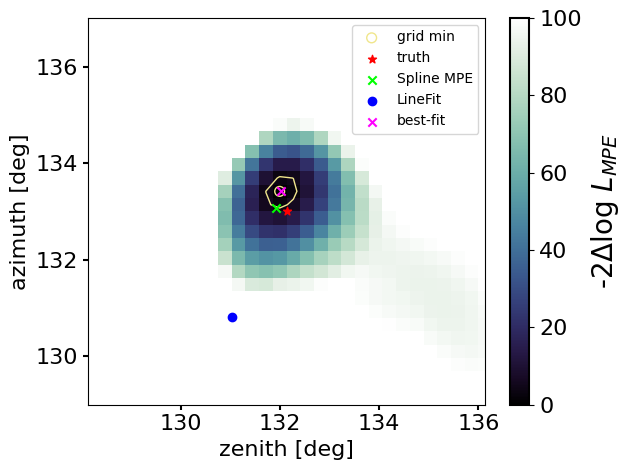

In [190]:
# Spline MPE Plot.
fig, ax = plt.subplots()
min_logl = np.amin(logls)
delta_logl = logls - np.amin(logls)
pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
# pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, shading='auto', cmap=cx)
cbar = fig.colorbar(pc)
cbar.ax.tick_params(labelsize=16)
cbar.ax.get_yaxis().labelpad = 5
cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
cbar.outline.set_linewidth(1.5)

contours = [4.61]
ix1, ix2 = np.where(delta_logl==0)
ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src1[0]), np.rad2deg(track_src1[1]), marker="x", color='lime', label="Spline MPE", zorder=200)
ax.scatter(np.rad2deg(track_src2[0]), np.rad2deg(track_src2[1]), marker="o", color='blue', label="LineFit", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))
ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)

plt.legend()
plt.tight_layout()
# plt.savefig(f"f32_scan_ev_{EVENT_INDEX}.png", dpi=300)
# plt.savefig(f"{ni}_scan_ev_{EVENT_INDEX}.png", dpi=300)
plt.show()

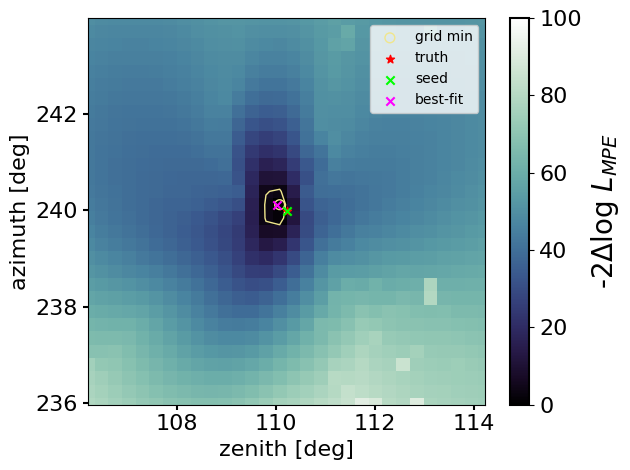

In [158]:
# Plot.
fig, ax = plt.subplots()
min_logl = np.amin(logls)
delta_logl = logls - np.amin(logls)
pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
# pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, shading='auto', cmap=cx)
cbar = fig.colorbar(pc)
cbar.ax.tick_params(labelsize=16)
cbar.ax.get_yaxis().labelpad = 5
cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
cbar.outline.set_linewidth(1.5)

contours = [4.61]
ix1, ix2 = np.where(delta_logl==0)
ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))
ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)

plt.legend()
plt.tight_layout()
# plt.savefig(f"f32_scan_ev_{EVENT_INDEX}.png", dpi=300)
# plt.savefig(f"{ni}_scan_ev_{EVENT_INDEX}.png", dpi=300)
plt.show()